In [2]:
#importing required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score

In [3]:
#loading Auto MPG dataset

url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df=pd.read_csv(url)
df.head()    #displays first five rows

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
#seperate i/p and o/p values

X=df[['displacement']]        #df-dataframe(shows values in table format)
Y=df[['mpg']]
print("Missing values in",X.isnull().sum() )      #to print the missing values in rows and columns of the dataset
print("Missing values in",Y.isnull().sum() )

Missing values in displacement    0
dtype: int64
Missing values in mpg    0
dtype: int64


In [5]:
data=df[['displacement','mpg']].dropna()       #to remove rows of missing values

#updates the i/p and o/p

X=data[['displacement']]
y=data[['mpg']]  
print("Feature:")      #prints the updated dataframe
print(X.head() )
print("\nTarget:")
print(Y.head() ) 

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
    mpg
0  18.0
1  15.0
2  18.0
3  16.0
4  17.0


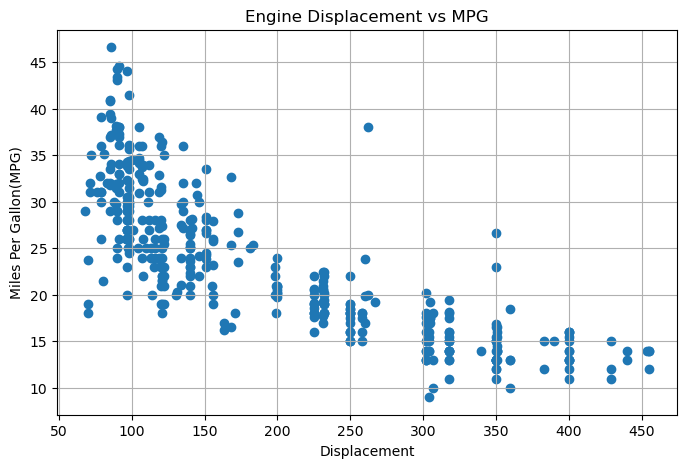

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(X,Y)
plt.xlabel("Displacement")
plt.ylabel("Miles Per Gallon(MPG)")
plt.title("Engine Displacement vs MPG")
plt.grid(True)      
plt.show()

In [7]:
#splitting the dataset

X_train,X_test, Y_train,Y_test=train_test_split(
    X,Y,test_size=0.2,random_state=42)

print("Training samples:",len(X_train) )
print("Testing samples:",len(X_test) )

Training samples: 318
Testing samples: 80


In [8]:
#creating a linear regression model

linear_model=LinearRegression()
linear_model.fit(X_train,Y_train)       #training the model
Y_pred_linear=linear_model.predict(X_test)   #predict on test data

In [9]:
mse_linear=mean_squared_error(Y_test,Y_pred_linear)
r2_linear=r2_score(Y_test,Y_pred_linear)
print("Linear Regression Model")
print("------------------------------")
print("MSE:",mse_linear)
print("R2 score:",r2_linear)

Linear Regression Model
------------------------------
MSE: 18.102543998358946
R2 score: 0.6633114869465595


In [22]:
results=[]      #to store results
polynomial_models={} #store polynomial models for plotting

#adding linear regression results
results.append({
    'Model':'Linear Regression',
    'Degree':1,
    'MSE':mse_linear,
    'R-squared':r2_linear
})

#trying polynomial degrees from 2 to 5

for degree in range(2,6):
      poly=PolynomialFeatures(degree=degree)
      X_train_poly=poly.fit_transform(X_train)
      X_test_poly=poly.transform(X_test)
      poly_model=LinearRegression()        #create lonear regressin model
      poly_model.fit(X_train_poly,Y_train)       #train polynomial regression model
      Y_pred_poly=poly_model.predict(X_test_poly)    #Make predictions
      mse=mean_squared_error(Y_test,Y_pred_poly)
      r2=r2_score(Y_test,Y_pred_poly)

      #store results
      results.append({
          'Model':'Polynomial Regression',
          'Degree':degree,
          'MSE':mse,
          'R-squared':r2
       })

      polynomial_models[degree]={
            'poly':poly,
            'model':poly_model  }    


In [25]:
results_df=pd.DataFrame(results)         #convert results to dataframe
results_df        #display results

,Model,Degree,MSE,R-squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


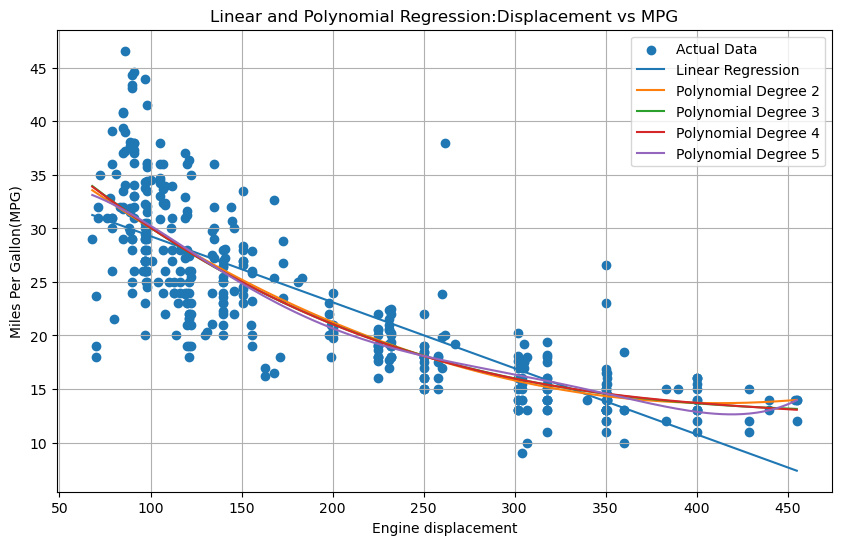

In [37]:
X_plot=pd.DataFrame({
'displacement':np.linspace(
    X['displacement'].min(),
    X['displacement'].max(),
    300)})

plt.figure(figsize=(10,6) )
plt.scatter(
    X['displacement'],
    Y,
    label='Actual Data' )

Y_plot_linear=linear_model.predict(X_plot)
plt.plot(
    X_plot['displacement'],
    Y_plot_linear,
    label='Linear Regression'
)

for degree in range(2,6):
    poly=polynomial_models[degree]['poly']
    poly_model=polynomial_models[degree]['model']
    X_plot_poly=poly.transform(X_plot)
    Y_plot_poly=poly_model.predict(X_plot_poly)
    plt.plot(
        X_plot['displacement'],
        Y_plot_poly,
        label=f'Polynomial Degree {degree}'
    )

#plot formatting
plt.xlabel('Engine displacement')
plt.ylabel('Miles Per Gallon(MPG)')
plt.title(
    'Linear and Polynomial Regression:Displacement vs MPG')
plt.legend()
plt.grid(True)
plt.show()

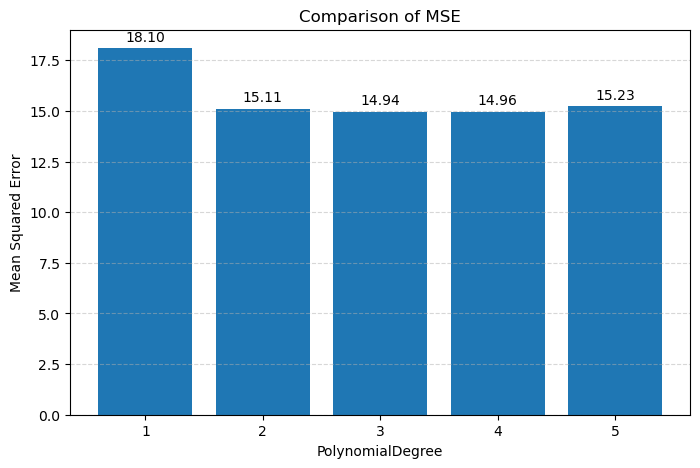

In [41]:
plt.figure(figsize=(8,5))
bars=plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)
plt.bar_label(bars,fmt='%.2f',padding=3)
plt.xlabel("PolynomialDegree")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of MSE")
plt.grid(axis='y',linestyle='--',alpha=0.5)  
plt.show()

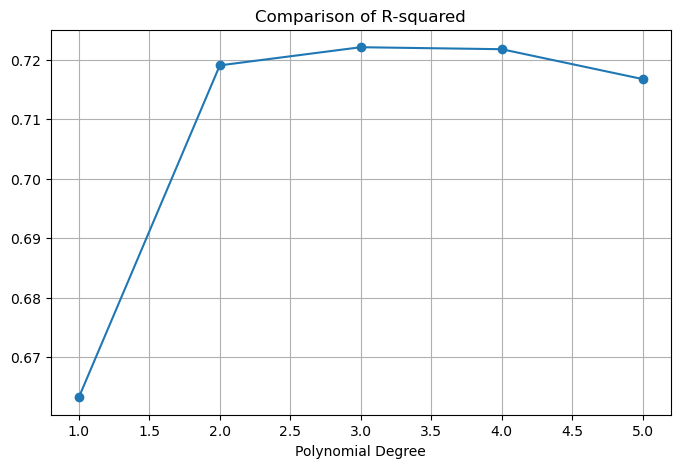

In [45]:
plt.figure(figsize=(8,5))
plt.plot(
    results_df['Degree'],
    results_df['R-squared'],
    marker='o' )
plt.xlabel("Polynomial Degree")
plt.ylabel=("R-squared")
plt.title("Comparison of R-squared")
plt.grid(True)
plt.show()